# Roads in Northern Ireland

In [12]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt

In [3]:
path_to_roads = os.path.join('..', 'data_geojson', 'OSNI_Open_Data_-_50K_Transport_-_Transport_lines.geojson')

gdf_roads = gpd.read_file(path_to_roads)

In [4]:
gdf_roads

,TEMA,SURVEY,SHAPE_Length,OBJECTID,geometry
0,MOTORWAY,20050114,328.110143,1,"LINESTRING (-6.21243 54.48706, -6.21652 54.48879)"
1,MOTORWAY,20050114,436.581250,2,"LINESTRING (-6.35014 54.48597, -6.35293 54.485..."
2,MOTORWAY,20050114,424.345572,3,"LINESTRING (-6.35521 54.48357, -6.35305 54.484..."
3,MOTORWAY,20050202,390.150259,4,"LINESTRING (-6.25336 54.8763, -6.25336 54.8763..."
4,MOTORWAY,20050202,128.443534,5,"LINESTRING (-6.25432 54.87731, -6.25362 54.876..."
...,...,...,...,...,...
25855,CL_RAIL,20020701,511.619530,25856,"LINESTRING (-5.94432 54.59202, -5.94005 54.593..."
25856,CL_RAIL,20011217,11414.396261,25857,"MULTILINESTRING ((-5.79934 54.84848, -5.80245 ..."
25857,CL_RAIL,20030601,467.455095,25858,"LINESTRING (-5.99292 54.56094, -5.98983 54.562..."
25858,CL_RAIL,20020701,3371.124487,25859,"LINESTRING (-5.98682 54.56382, -5.98353 54.564..."


Check which types of roads are present:

In [5]:
sorted(list(set(gdf_roads['TEMA'])))

['<4M_TARRED',
 '<4M_T_OVER',
 'A_CLASS',
 'B_CLASS',
 'CL_MINOR',
 'CL_M_OVER',
 'CL_RAIL',
 'DUAL_CARR',
 'MOTORWAY',
 'RL_TUNNEL',
 'UNSHOWN_RL']

Keep only motorways and A roads:

In [6]:
mask = gdf_roads['TEMA'].isin(['MOTORWAY', 'A_CLASS'])

In [7]:
gdf_roads = gdf_roads[mask]

gdf_roads

,TEMA,SURVEY,SHAPE_Length,OBJECTID,geometry
0,MOTORWAY,20050114,328.110143,1,"LINESTRING (-6.21243 54.48706, -6.21652 54.48879)"
1,MOTORWAY,20050114,436.581250,2,"LINESTRING (-6.35014 54.48597, -6.35293 54.485..."
2,MOTORWAY,20050114,424.345572,3,"LINESTRING (-6.35521 54.48357, -6.35305 54.484..."
3,MOTORWAY,20050202,390.150259,4,"LINESTRING (-6.25336 54.8763, -6.25336 54.8763..."
4,MOTORWAY,20050202,128.443534,5,"LINESTRING (-6.25432 54.87731, -6.25362 54.876..."
...,...,...,...,...,...
4092,A_CLASS,20060308,7.224823,4093,"LINESTRING (-6.49209 54.76229, -6.49209 54.762..."
4093,A_CLASS,20060308,52.733862,4094,"LINESTRING (-6.49274 54.76211, -6.4927 54.7621..."
4094,A_CLASS,20060308,51.742728,4095,"LINESTRING (-6.49298 54.7625, -6.493 54.76247,..."
4095,A_CLASS,20060308,22.209081,4096,"LINESTRING (-6.45642 54.75936, -6.45642 54.759..."


Check which roads are left:

<Axes: >

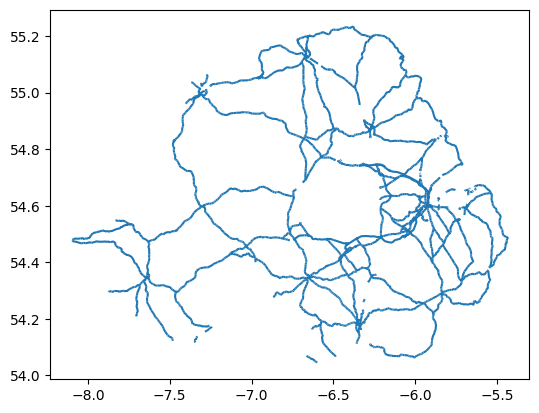

In [8]:
gdf_roads.plot()

Save to file:

In [9]:
gdf_roads.to_file('major_roads_ni.geojson')

## Set precision

Reduce the precision of the points. For our purposes, we don't need the road coordinates to be precise to the nearest centimetre. Change them to be accurate to the nearest kilometre.

In [18]:
gdf_roads.to_crs('EPSG:29902')

,TEMA,SURVEY,SHAPE_Length,OBJECTID,geometry
0,MOTORWAY,20050114,328.110143,1,"LINESTRING (315895.153 361316.725, 315624.908 ..."
1,MOTORWAY,20050114,436.581250,2,"LINESTRING (306974.319 360977.626, 306794.13 3..."
2,MOTORWAY,20050114,424.345572,3,"LINESTRING (306651.889 360703.015, 306789.908 ..."
3,MOTORWAY,20050202,390.150259,4,"LINESTRING (312164.785 404574.117, 312164.8 40..."
4,MOTORWAY,20050202,128.443534,5,"LINESTRING (312100.141 404684.89, 312147.343 4..."
...,...,...,...,...,...
4092,A_CLASS,20060308,7.224823,4093,"LINESTRING (297114.688 391527.94, 297115.154 3..."
4093,A_CLASS,20060308,52.733862,4094,"LINESTRING (297073.454 391506.277, 297075.951 ..."
4094,A_CLASS,20060308,51.742728,4095,"LINESTRING (297057.105 391549.189, 297055.972 ..."
4095,A_CLASS,20060308,22.209081,4096,"LINESTRING (299418.037 391251.594, 299417.911 ..."


In [28]:
gdf_precision = gdf_roads.copy()

# Convert to Irish National Grid:
gdf_precision = gdf_precision.to_crs('EPSG:29902')

gdf_precision['geometry'] = gdf_precision['geometry'].set_precision(grid_size=500)
gdf_precision['geometry'] = gdf_precision['geometry'].remove_repeated_points()

In [29]:
gdf_precision

,TEMA,SURVEY,SHAPE_Length,OBJECTID,geometry
0,MOTORWAY,20050114,328.110143,1,"LINESTRING (316000 361500, 315500 361500)"
1,MOTORWAY,20050114,436.581250,2,"LINESTRING (307000 361000, 306500 361000)"
2,MOTORWAY,20050114,424.345572,3,"LINESTRING (306500 360500, 307000 361000)"
3,MOTORWAY,20050202,390.150259,4,"LINESTRING (312000 404500, 312500 404500, 3125..."
4,MOTORWAY,20050202,128.443534,5,LINESTRING Z EMPTY
...,...,...,...,...,...
4092,A_CLASS,20060308,7.224823,4093,LINESTRING Z EMPTY
4093,A_CLASS,20060308,52.733862,4094,LINESTRING Z EMPTY
4094,A_CLASS,20060308,51.742728,4095,LINESTRING Z EMPTY
4095,A_CLASS,20060308,22.209081,4096,LINESTRING Z EMPTY


Quick plot of the results:

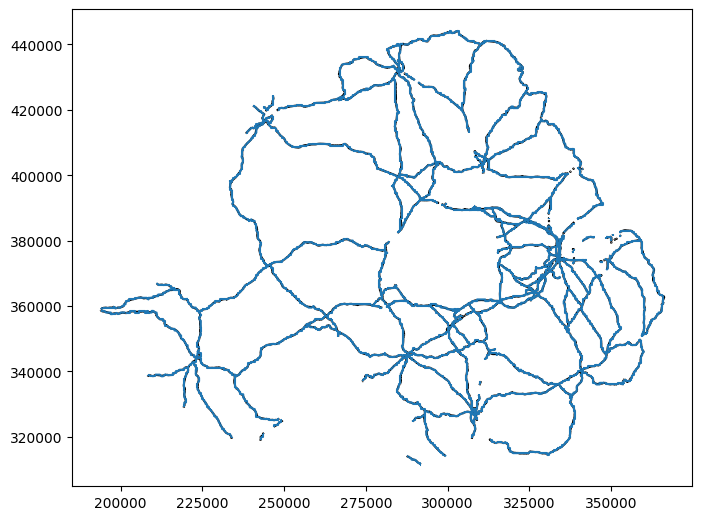

In [31]:
fig, ax = plt.subplots(figsize=(8, 10))

gdf_roads.to_crs('EPSG:29902').plot(ax=ax, color='k')
gdf_precision.plot(ax=ax)

plt.show()

Save results to file:

In [32]:
gdf_precision[['TEMA', 'OBJECTID', 'geometry']].to_file('major_roads_ni_precision.geojson')

File size is under 1MB.